# Worked Examples

These examples use public Blueprint hub tracks and focus on realistic PlotNado workflows built from real files.

In [4]:
from pathlib import Path
import plotnado

from plotnado import GenomicFigure, PlotStyle

rna_gene_of_interest = "ACTB"
monocyte_gene_of_interest = "LYZ"
repo_root = Path(plotnado.__file__).resolve().parent.parent
blueprint_bigwig_files = {
    "T12-15 plasma cell RNA": "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/tonsil/T12-15/plasma_cell/RNA-Seq/IDIBAPS/T12-15-PC.signal.star_grape2_crg.GRCh38.20150815.bw",
    "T12-16 plasma cell RNA": "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/tonsil/T12-16/plasma_cell/RNA-Seq/IDIBAPS/T12-16-PC.signal.star_grape2_crg.GRCh38.20150815.bw",
}
blueprint_monocyte_h3k27ac_signal = "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/venous_blood/C000S5/CD14-positive_CD16-negative_classical_monocyte/ChIP-Seq/NCMLS/C000S5H2.ERX173536.H3K27ac.bwa.GRCh38.20150529.bw"
blueprint_monocyte_h3k27ac_peaks = "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/venous_blood/C000S5/CD14-positive_CD16-negative_classical_monocyte/ChIP-Seq/NCMLS/C000S5H2.ERX173536.H3K27ac.bwa.GRCh38.20150527.bb"
blueprint_monocyte_candidate_bed = repo_root / "examples" / "data" / "blueprint_monocyte_lyz_candidate_peaks.bed"

## Example 1: stacked Blueprint BigWig tracks with label boxes

This mirrors the main workflow closely: two real Blueprint RNA BigWig files, separate panels, and the track title and scale drawn inside the plotted area with a visible background box.

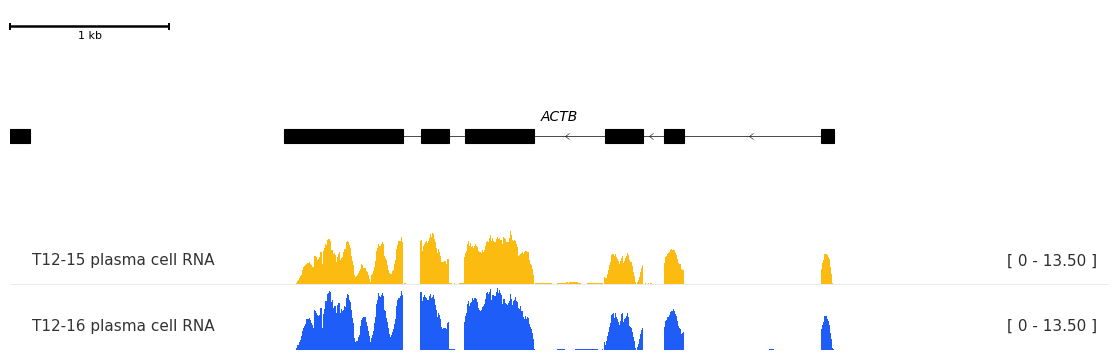

In [5]:
stacked_fig = GenomicFigure()
stacked_fig.scalebar()
stacked_fig.genes("hg38")
stacked_fig.autocolor()

for name, url in blueprint_bigwig_files.items():
    stacked_fig.bigwig(
        url,
        title=name,
        style=PlotStyle.FRAGMENT,
        height=0.55,
        autoscale_group="blueprint_rna",
        label_on_track=True,
        label_box_enabled=True,
        label_box_alpha=0.95,
        title_height=0.5,
        scale_height=0.5,
        plot_scale=True,
    )

stacked_plot = stacked_fig.plot_gene(rna_gene_of_interest)
stacked_plot

## Example 2: Blueprint `bigwig_overlay()` with a shared axis

`bigwig_overlay()` is the clearer API for this case. It resolves to the same implementation as `overlay()`, but the current implementation auto-wraps path inputs as `BigWigTrack`, so the more specific name matches the actual behavior better. The overlay now accepts the same `style` kwarg as `bigwig()`, so this example uses `PlotStyle.FRAGMENT` to keep the signal geometry consistent with the stacked panels above.

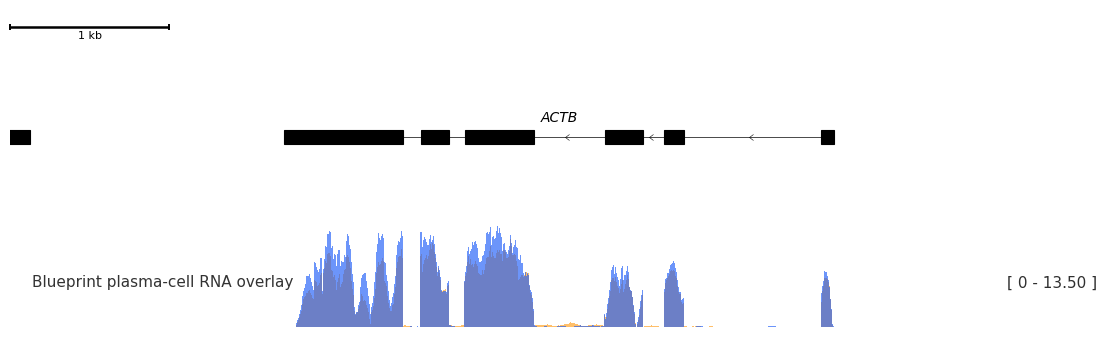

In [3]:
overlay_fig = GenomicFigure()
overlay_fig.scalebar()
overlay_fig.genes("hg38")
overlay_fig.bigwig_overlay(
    list(blueprint_bigwig_files.values()),
    title="Blueprint plasma-cell RNA overlay",
    style=PlotStyle.FRAGMENT,
    colors=["#FF9D1B", "#1E5DF8"],
    alpha=0.65,
    height=0.9,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.5,
    scale_height=0.5,
    plot_scale=True,
)

overlay_plot = overlay_fig.plot_gene(rna_gene_of_interest)
overlay_plot

## Example 3: a real review plot with Blueprint `BigWig`, Blueprint `bigBed`, and a checked-in `BED`

This mirrors a more realistic workflow: inspect a public signal track, compare it to the hub's peak calls, and add a checked-in BED file that captures the loci you want to revisit after review.

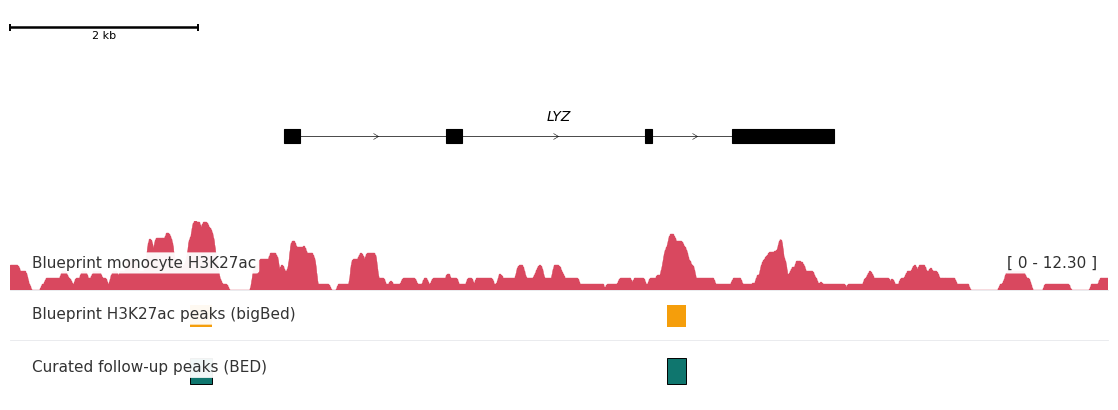

In [4]:
review_fig = GenomicFigure()
review_fig.scalebar()
review_fig.genes("hg38")
review_fig.bigwig(
    blueprint_monocyte_h3k27ac_signal,
    title="Blueprint monocyte H3K27ac",
    style=PlotStyle.FRAGMENT,
    height=0.6,
    color="#d9485f",
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.5,
    scale_height=0.5,
    plot_scale=True,
)
review_fig.bed(
    blueprint_monocyte_h3k27ac_peaks,
    title="Blueprint H3K27ac peaks (bigBed)",
    color="#f59e0b",
    draw_edges=False,
    height=0.42,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.7,
    show_labels=False,
)
review_fig.bed(
    str(blueprint_monocyte_candidate_bed),
    title="Curated follow-up peaks (BED)",
    color="#0f766e",
    draw_edges=True,
    show_labels=True,
    label_field="name",
    font_size=7,
    height=0.5,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.7,
)

review_plot = review_fig.plot_gene(monocyte_gene_of_interest)
review_plot

## Example 4: start from a public UCSC hub and keep the notebook interactive

`GenomicFigure.from_ucsc_hub()` can flatten supported tracks from a UCSC-style hub directly into a PlotNado figure. This Blueprint hub expands to a larger review figure than you usually want on first render, so the example below keeps just the H3K27ac peak/signal pair and the stranded RNA tracks visible, then uses `track_visibility_widget()` to turn the rest back on as needed.

The widget is notebook-only and requires `ipywidgets`, either via `pip install "plotnado[notebook]"` or `uv pip install ipywidgets`.

In [6]:
from plotnado import GenomicFigure

blueprint_hub_url = "https://ftp.ebi.ac.uk/pub/databases/blueprint/releases/current_release/homo_sapiens/hub/hub.txt"
lyz_region = "chr12:6908053-6997143"

hub_fig = GenomicFigure.from_ucsc_hub(
    blueprint_hub_url,
    genome="hg38",
    include_hidden=False,
)

hub_keep_tokens = (
    "H3K27ac MASC2_peak",
    "H3K27ac MACS2_wiggler",
    "RNA-Seq RNAMinus ",
    "RNA-Seq RNAPlus ",
)

for track in getattr(hub_fig, "tracks", []):
    title = getattr(track, "title", "") or ""
    if track.__class__.__name__ in {"ScaleBar", "GenomicAxis"}:
        continue
    if not any(token in title for token in hub_keep_tokens):
        track.height = 0.0

hub_widget = hub_fig.track_visibility_widget(lyz_region)
hub_widget